# 🚗 Used Car Price Prediction

## Notebook 2: Machine Learning Model Development

### Objective

This notebook focuses on preparing the dataset for machine learning, training multiple regression models, comparing their performance, and saving the best model.

**Note:** Data cleaning and exploratory data analysis were completed in Notebook 1.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

In [2]:
# Load Dataset

df = pd.read_csv("/kaggle/input/datasets/chandanikumari7/clean-car-dataset/cleaned_used_cars.xls")

In [3]:
# Remove Duplicates

df = df.drop_duplicates()


In [4]:
# Handle Missing Values

df['fuel'] = df['fuel'].fillna(df['fuel'].mode()[0])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357751 entries, 0 to 357750
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                357751 non-null  int64  
 1   url               357751 non-null  object 
 2   region            357751 non-null  object 
 3   region_url        357751 non-null  object 
 4   price             357751 non-null  int64  
 5   year              357751 non-null  int64  
 6   manufacturer      357751 non-null  object 
 7   model             357751 non-null  object 
 8   condition         357751 non-null  object 
 9   cylinders         357751 non-null  object 
 10  fuel              357751 non-null  object 
 11  odometer          357751 non-null  int64  
 12  title_status      357751 non-null  object 
 13  transmission      357751 non-null  object 
 14  drive             357751 non-null  object 
 15  type              357751 non-null  object 
 16  paint_color       35

In [6]:
drop_columns = [

    'id',

    'url',

    'region_url'

]

df = df.drop(columns=drop_columns)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357751 entries, 0 to 357750
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   region            357751 non-null  object 
 1   price             357751 non-null  int64  
 2   year              357751 non-null  int64  
 3   manufacturer      357751 non-null  object 
 4   model             357751 non-null  object 
 5   condition         357751 non-null  object 
 6   cylinders         357751 non-null  object 
 7   fuel              357751 non-null  object 
 8   odometer          357751 non-null  int64  
 9   title_status      357751 non-null  object 
 10  transmission      357751 non-null  object 
 11  drive             357751 non-null  object 
 12  type              357751 non-null  object 
 13  paint_color       357751 non-null  object 
 14  state             357751 non-null  object 
 15  lat               357751 non-null  float64
 16  long              35

# Phase 3

## Machine Learning

In [7]:
# Select Features

X = df.drop(columns=['price'])

y = df['price']

print(X.shape)
print(y.shape)

(357751, 20)
(357751,)


In [8]:
# Drop Unnecessary Columns

X = X.drop(columns=[

    'posting_date',

    'lat',

    'long'

])

X.head()

,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,car_age,mileage_per_year,is_luxury
0,auburn,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923,clean,other,Unknown,pickup,white,al,8,6435.888889,0
1,auburn,2010,chevrolet,silverado 1500,good,8 cylinders,gas,71229,clean,other,Unknown,pickup,blue,al,12,5479.153846,0
2,auburn,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160,clean,other,Unknown,pickup,red,al,2,6386.666667,0
3,auburn,2017,toyota,tundra double cab sr,good,8 cylinders,gas,41124,clean,other,Unknown,pickup,red,al,5,6854.000000,0
4,auburn,2013,ford,f-150 xlt,excellent,6 cylinders,gas,128000,clean,automatic,rwd,truck,black,al,9,12800.000000,0


In [9]:
# Numerical Features

numerical_features = [

    'year',

    'odometer',

    'car_age',

    'mileage_per_year',

    'is_luxury'

]

In [10]:
# Categorical Features

categorical_features = [

    'region',

    'manufacturer',

    'model',

    'condition',

    'cylinders',

    'fuel',

    'title_status',

    'transmission',

    'drive',

    'type',

    'paint_color',

    'state'

]

In [11]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(286200, 17)
(71551, 17)


In [12]:
# Preprocessing

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(

    transformers=[

        (

            'cat',

            OneHotEncoder(handle_unknown='ignore'),

            categorical_features

        )

    ],

    remainder='passthrough'

)

In [13]:
# Import Models

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Linear Regression

In [18]:
linear_model = Pipeline([

    ('preprocessor', preprocessor),

    ('model', LinearRegression())

])

linear_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'manufacturer',
                                                   'model', 'condition',
                                                   'cylinders', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'type', 'paint_color',
                                                   'state'])])),
                ('model', LinearRegression())])

In [19]:
y_pred_lr = linear_model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print()

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R² Score :", round(r2,4))

Linear Regression Results

MAE : 6269.78
RMSE : 9137.48
R² Score : 0.6027


## Decision Tree Regressor

In [21]:
decision_tree = Pipeline([

    ('preprocessor', preprocessor),

    ('model', DecisionTreeRegressor(

        random_state=42,

        max_depth=20

    ))

])

decision_tree.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'manufacturer',
                                                   'model', 'condition',
                                                   'cylinders', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'type', 'paint_color',
                                                   'state'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=20, random_state=42))])

In [22]:
y_pred_dt = decision_tree.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test, y_pred_dt)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print()

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R² Score :", round(r2,4))

Decision Tree Results

MAE : 3300.33
RMSE : 6129.99
R² Score : 0.8212


## Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline([

    ('preprocessor', preprocessor),

    ('model', RandomForestRegressor(

        n_estimators=30,

        max_depth=20,

        max_features='sqrt',

        random_state=42,

        n_jobs=-1

    ))

])

random_forest.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'manufacturer',
                                                   'model', 'condition',
                                                   'cylinders', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'type', 'paint_color',
                                                   'state'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       n_estimators=30, n_jobs=-1,
                                       random_state=42))])

In [27]:
y_pred_rf = random_forest.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test, y_pred_rf)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print()

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

Random Forest Results

MAE : 8904.32
RMSE : 11804.51
R² Score : 0.3369


## CatBoost Regressor

In [30]:
!pip install catboost -q

In [31]:
from catboost import CatBoostRegressor

In [32]:
X_cb = df.drop(columns=['price'])

X_cb = X_cb.drop(columns=[

    'posting_date',

    'lat',

    'long'

])

y_cb = df['price']

In [33]:
from sklearn.model_selection import train_test_split

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(

    X_cb,

    y_cb,

    test_size=0.2,

    random_state=42

)

In [39]:
categorical_features = X_train_cb.select_dtypes(include='object').columns.tolist()

categorical_features

['region',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'state']

In [40]:
cat_model = CatBoostRegressor(

    iterations=500,

    learning_rate=0.1,

    depth=8,

    loss_function='RMSE',

    eval_metric='RMSE',

    random_seed=42,

    verbose=100

)

In [45]:
cat_model.fit(

    X_train_cb,

    y_train_cb,

    cat_features=cat_features,

    eval_set=(X_test_cb, y_test_cb),

    use_best_model=True

)

0:	learn: 13569.4802968	test: 13584.3960135	best: 13584.3960135 (0)	total: 740ms	remaining: 6m 9s
100:	learn: 6061.2614392	test: 5962.4814230	best: 5962.4814230 (100)	total: 51.1s	remaining: 3m 21s
200:	learn: 5604.2282069	test: 5540.6332634	best: 5540.6332634 (200)	total: 1m 43s	remaining: 2m 33s
300:	learn: 5365.8642553	test: 5344.7760911	best: 5344.7760911 (300)	total: 2m 33s	remaining: 1m 41s
400:	learn: 5157.1800866	test: 5191.2986061	best: 5191.2986061 (400)	total: 3m 24s	remaining: 50.6s
499:	learn: 5027.0089300	test: 5103.9351290	best: 5103.9351290 (499)	total: 4m 14s	remaining: 0us

bestTest = 5103.935129
bestIteration = 499



CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

In [42]:
X_train_cb.dtypes

region               object
year                  int64
manufacturer         object
model                object
condition            object
cylinders            object
fuel                 object
odometer              int64
title_status         object
transmission         object
drive                object
type                 object
paint_color          object
state                object
car_age               int64
mileage_per_year    float64
is_luxury             int64
dtype: object

In [43]:
cat_features = [

    X_train_cb.columns.get_loc(col)

    for col in categorical_features

]

print(cat_features)

[0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13]


In [46]:
y_pred_cat = cat_model.predict(X_test_cb)

In [47]:
mae = mean_absolute_error(y_test_cb, y_pred_cat)

rmse = np.sqrt(mean_squared_error(y_test_cb, y_pred_cat))

r2 = r2_score(y_test_cb, y_pred_cat)

print("CatBoost Results")
print()

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

CatBoost Results

MAE : 2947.31
RMSE : 5103.94
R² Score : 0.876


# Phase 4

## Model Comparison and Best Model Selection

In [48]:
results = pd.DataFrame({

    'Model': [

        'Linear Regression',

        'Decision Tree',

        'Random Forest',

        'CatBoost'

    ],

    'MAE': [

        6269.78,

        3300.33,

        8904.32,

        2947.31

    ],

    'RMSE': [

        9137.48,

        6129.99,

        11804.51,

        5103.94

    ],

    'R2 Score': [

        0.6027,

        0.8212,

        0.3369,

        0.8760

    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,6269.78,9137.48,0.6027
1,Decision Tree,3300.33,6129.99,0.8212
2,Random Forest,8904.32,11804.51,0.3369
3,CatBoost,2947.31,5103.94,0.8760


In [49]:
results.sort_values(

    by='R2 Score',

    ascending=False

)

,Model,MAE,RMSE,R2 Score
3,CatBoost,2947.31,5103.94,0.8760
1,Decision Tree,3300.33,6129.99,0.8212
0,Linear Regression,6269.78,9137.48,0.6027
2,Random Forest,8904.32,11804.51,0.3369


### Best Model

Based on model evaluation, **CatBoost Regressor** achieved the highest R² Score and the lowest prediction error.

Therefore, CatBoost is selected as the final model for deployment.

In [50]:
import joblib

joblib.dump(

    cat_model,

    "best_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [51]:
joblib.load(

    "best_model.pkl"

)

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

# Phase 5

## Feature Importance

In [52]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({

    'Feature': X_train_cb.columns,

    'Importance': cat_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False

)

feature_importance.head(10)

,Feature,Importance
1,year,16.598229
7,odometer,11.058233
14,car_age,8.847653
3,model,8.804440
5,cylinders,8.082708
2,manufacturer,7.977479
10,drive,7.922304
11,type,6.766621
6,fuel,6.662725
4,condition,5.673596


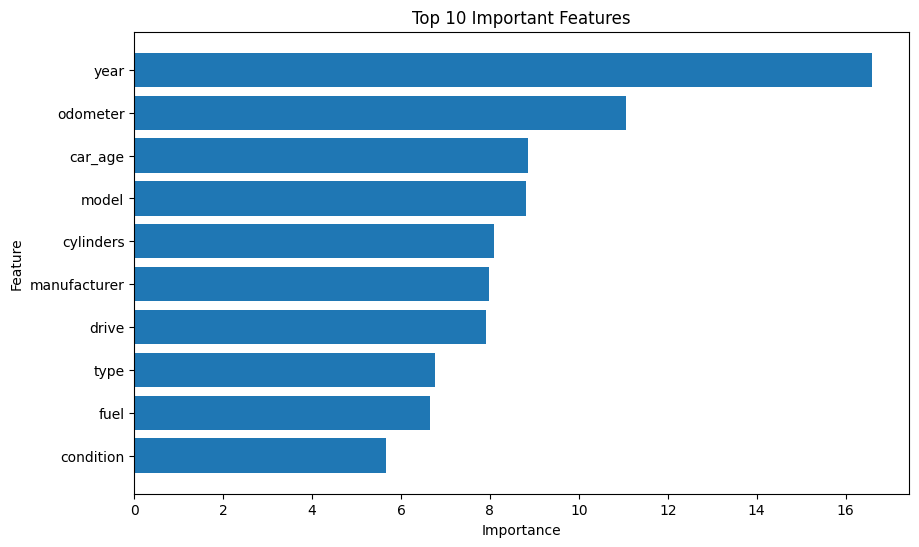

In [53]:
plt.figure(figsize=(10,6))

plt.barh(

    feature_importance['Feature'][:10],

    feature_importance['Importance'][:10]

)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [54]:
sample = X_test_cb.iloc[[0]]

prediction = cat_model.predict(sample)

print("Predicted Price :", prediction[0])

print("Actual Price :", y_test_cb.iloc[0])

Predicted Price : 2505.997393229325
Actual Price : 4477


In [55]:
manufacturers = sorted(df['manufacturer'].unique())

models = sorted(df['model'].unique())

fuel_types = sorted(df['fuel'].unique())

transmissions = sorted(df['transmission'].unique())

vehicle_types = sorted(df['type'].unique())

states = sorted(df['state'].unique())

In [56]:
import joblib

joblib.dump(manufacturers, "manufacturers.pkl")

joblib.dump(models, "models.pkl")

joblib.dump(fuel_types, "fuel_types.pkl")

joblib.dump(transmissions, "transmissions.pkl")

joblib.dump(vehicle_types, "vehicle_types.pkl")

joblib.dump(states, "states.pkl")

print("All files saved successfully")

All files saved successfully


In [58]:
import os

os.listdir()

['vehicle_types.pkl',
 'manufacturers.pkl',
 'transmissions.pkl',
 '.virtual_documents',
 'fuel_types.pkl',
 'states.pkl',
 'catboost_info',
 'best_model.pkl',
 'models.pkl']